# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

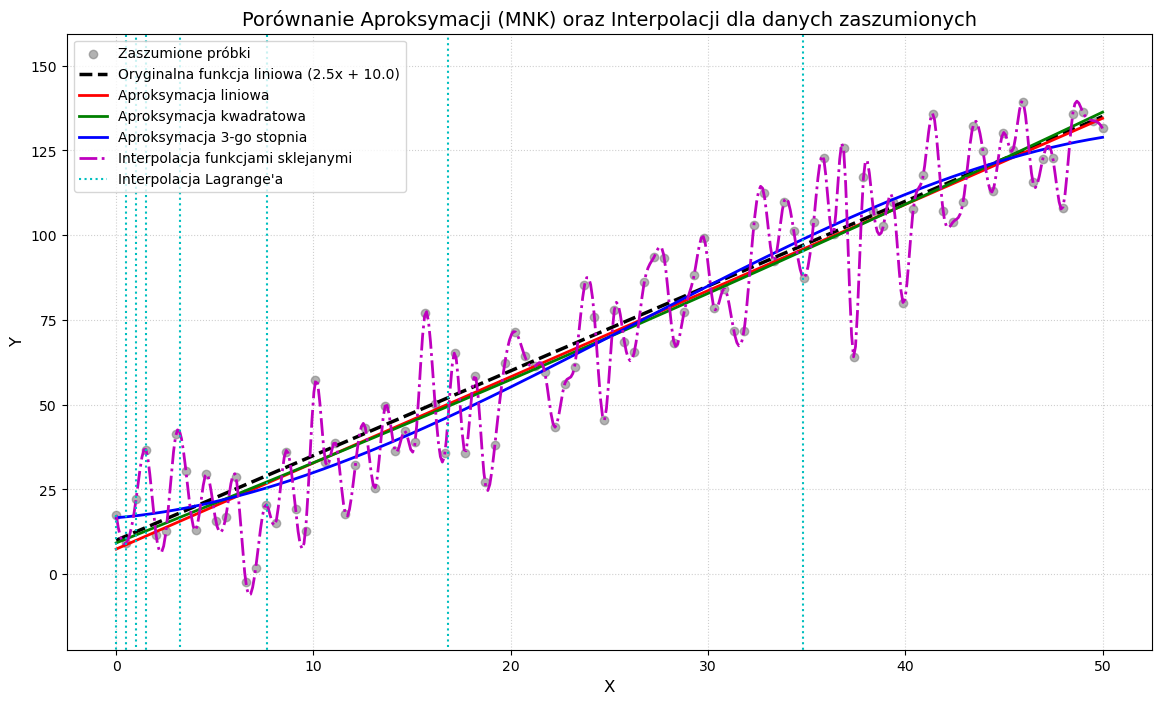

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, CubicSpline

# Dowolne parametry a i b dla funkcji liniowej f(x) = ax + b
a_true = 2.5
b_true = 10.0

def linear_func(x, a, b):
    return a * x + b

# Wygenerowanie 100 punktów z przedziału [0, 50]
np.random.seed(42) # Stałe ziarno dla powtarzalności wyników
x_data = np.linspace(0, 50, 100)
y_true = linear_func(x_data, a_true, b_true)

# Dodanie szumu losowego (rozkład normalny)
noise = np.random.normal(0, 15, 100) # średnia=0, odchylenie standardowe=15
y_noisy = y_true + noise

# Gęsta siatka punktów do płynnego rysowania modeli aproksymacyjnych i interpolacji
x_dense = np.linspace(0, 50, 500)

# Modele do aproksymacji
def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

def cubic_func(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

# Dopasowanie modeli do zaszumionych danych
popt_lin, _ = curve_fit(linear_func, x_data, y_noisy)
popt_quad, _ = curve_fit(quadratic_func, x_data, y_noisy)
popt_cubic, _ = curve_fit(cubic_func, x_data, y_noisy)

# Obliczenie wartości dla aproksymacji
y_approx_lin = linear_func(x_dense, *popt_lin)
y_approx_quad = quadratic_func(x_dense, *popt_quad)
y_approx_cubic = cubic_func(x_dense, *popt_cubic)

# UWAGA: Interpolacja wielomianem Lagrange'a dla 100 punktów ucierpi na 
# efekt Rungego (niestabilność numeryczna). To świetne porównanie z aproksymacją.

# Interpolacja Lagrange'a
poly_lagrange = lagrange(x_data, y_noisy)
y_interp_lagrange = poly_lagrange(x_dense)

# Interpolacja funkcjami sklejanymi (Cubic Spline - trzeciego stopnia)
cs = CubicSpline(x_data, y_noisy)
y_interp_spline = cs(x_dense)


plt.figure(figsize=(14, 8))

# Dane oryginalne i zaszumione
plt.scatter(x_data, y_noisy, color='gray', alpha=0.6, label='Zaszumione próbki', zorder=2)
plt.plot(x_data, y_true, 'k--', linewidth=2.5, label=f'Oryginalna funkcja liniowa ({a_true}x + {b_true})')

# Wykresy aproksymacji (MNK)
plt.plot(x_dense, y_approx_lin, 'r-', linewidth=2, label='Aproksymacja liniowa')
plt.plot(x_dense, y_approx_quad, 'g-', linewidth=2, label='Aproksymacja kwadratowa')
plt.plot(x_dense, y_approx_cubic, 'b-', linewidth=2, label='Aproksymacja 3-go stopnia')

# Wykresy interpolacji
# Ograniczamy widoczność Lagrange'a na wykresie, ponieważ jego ekstrema potrafią "wystrzelić" do nieskończoności
plt.plot(x_dense, y_interp_spline, 'm-.', linewidth=2, label='Interpolacja funkcjami sklejanymi')
plt.plot(x_dense, y_interp_lagrange, 'c:', linewidth=1.5, label='Interpolacja Lagrange\'a')

# Konfiguracja osi i estetyka wykresu
plt.title('Porównanie Aproksymacji (MNK) oraz Interpolacji dla danych zaszumionych', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.ylim(min(y_noisy) - 20, max(y_noisy) + 20) # Ograniczenie osi Y, by dzikie oscylacje Lagrange'a nie zepsuły skali
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).